## Redes Convolucionales
#### Ejemplo clasificación de perros y gatos para CAPTCHA

Este notebook utiliza datos de la [competición de Kaggle Dogs vs. Cats](https://www.kaggle.com/c/dogs-vs-cats/overview). En esta competicion se utiliza Asirra (Animal Species Image Recognition for Restricting Access), CAPTCHA que sirve para diferenciar entre una persona o una máquina accediendo a una página web. Este tipo de "pruebas" se utilizan para evitar emails de spam, y ataques por fuerza bruta contra servidores.

En este notebook vamos a probar que hay técnicas de clasificado automáticas de imágenes mediante redes neuronales, que con las que se intenta saltar CAPTCHA

# Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random
import os

# Define Constants
Tendremos una serie de constantes como las dimensiones de las imágenes, que serán fijas a lo largo de todo el notebook

In [2]:
IMAGE_WIDTH=100
IMAGE_HEIGHT=100
IMAGE_CHANNELS=3
IMAGE_SIZE=(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)
BATCH_SIZE = 32
EPOCHS = 25

# Prepare Training Data
1. Descárgate el dataset
2. Descomprime el dataset y guardalo en la ruta que quieras del ordenador.
3. En este punto vamos guardar en una lista las etiquetas de cada foto.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!ls /content/drive/MyDrive/data_dogs_cats/

PROF_test1.zip	PROF_train.zip


In [ ]:
import os
print(os.getcwd()) # Imprime la ruta actual
print(os.listdir()) # Lista los archivos que Python ve en esa carpeta
ruta = "/home/danilavia/Documents/work/ds_curso/4-Deep_Learning/2-Redes_Convolucionales/"

/content
['.config', 'sample_data']


In [ ]:
import zipfile
import os
ruta_zip = "PROF_train.zip"          # Ruta del ZIP
#destino = "carpeta_destino" # Carpeta donde se extraerá

# Crear carpeta destino si no existe
# os.makedirs(destino, exist_ok=True)

with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall()

print("Descompresión de train completada.")


NameError: name 'destino' is not defined

In [5]:
ruta_zip = "PROF_test1.zip"          # Ruta del ZIP
#destino = "carpeta_destino" # Carpeta donde se extraerá

# Crear carpeta destino si no existe
# os.makedirs(destino, exist_ok=True)

with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall()

print("Descompresión de test completada.")

Descompresión de test completada.


In [4]:
from pathlib import Path

ROOT_PATH = os.getcwd()

#TRAIN_PATH = ROOT_PATH + "\\data\\PROF_train\\PROF_train\\train\\"
#TEST_PATH = ROOT_PATH + "\\data\\PROF_test1\\PROF_test1\\test1\\"


ruta_base = Path(ROOT_PATH)
carpeta = "PROF_train"
carpeta2 = "train"

TRAIN_PATH = ruta_base / carpeta / carpeta2


carpeta = "PROF_test1"
carpeta2 = "test1"

TEST_PATH = ruta_base  / carpeta / carpeta2


In [12]:
'''

# Listar todos los archivos de la carpeta de train (TRAIN_PATH)
filenames = os.listdir(TRAIN_PATH)

# Lista vacia
categories = []

# Iterar
for filename in filenames:
    # Saco el nombre
    category = filename.split('.')[0]

    # If else
    # Guardo en lista
    if category == 'dog':
        categories.append(1)
    else:
        categories.append(0)


df = pd.DataFrame({
    'filename': filenames,
    'category': categories
})
'''

In [13]:
# df

,filename,category
0,dog.7849.jpg,1
1,dog.8391.jpg,1
2,dog.884.jpg,1
3,cat.10156.jpg,0
4,dog.2700.jpg,1
...,...,...
24995,cat.9097.jpg,0
24996,cat.253.jpg,0
24997,cat.4638.jpg,0
24998,cat.5032.jpg,0


In [14]:
from sklearn.utils import shuffle
#for vez in range(10000):
df = shuffle(df)

In [15]:
df

,filename,category
11848,dog.373.jpg,1
11107,dog.5142.jpg,1
22311,dog.854.jpg,1
22982,dog.2680.jpg,1
11672,cat.9291.jpg,0
...,...,...
18490,dog.7337.jpg,1
19848,dog.9671.jpg,1
13256,cat.9474.jpg,0
4147,dog.1219.jpg,1


### See Total In count

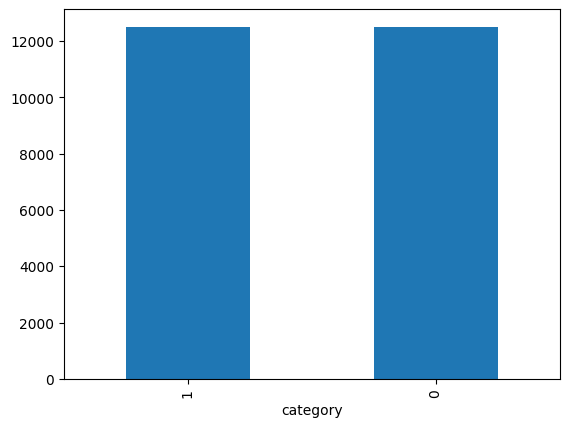

In [16]:
df['category'].value_counts().plot.bar();

# See sample image

In [7]:
from skimage.io import imread
import cv2

(439, 500, 3)
255


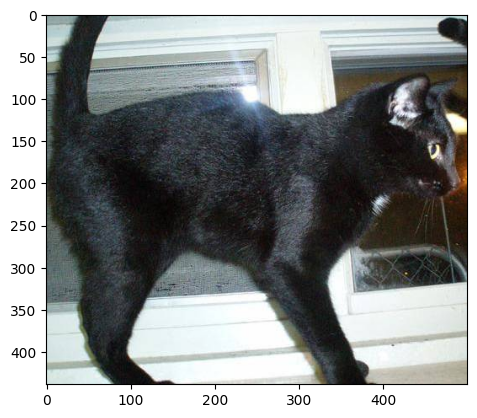

In [ ]:
filenames = os.listdir(TRAIN_PATH)
sample = random.choice(filenames)
image = imread(TRAIN_PATH / sample)

print(image.shape)
print(np.max(image))
plt.imshow(image);

Una imagen no es mas que un array de HxWxC píxeles, siendo H(Height) y W(Width) las dimensiones de resolución de la imagen, y C el número de canales. Habrá tres valores por píxel.

array([[[145, 165, 164],
        [143, 163, 162],
        [141, 161, 160],
        ...,
        [193, 211, 213],
        [192, 210, 212],
        [186, 204, 206]],

       [[132, 152, 151],
        [132, 152, 151],
        [133, 153, 152],
        ...,
        [202, 220, 222],
        [202, 220, 222],
        [198, 216, 218]],

       [[138, 158, 157],
        [137, 157, 156],
        [136, 156, 155],
        ...,
        [192, 211, 215],
        [193, 212, 216],
        [191, 210, 214]],

       ...,

       [[212, 227, 224],
        [212, 227, 224],
        [212, 227, 224],
        ...,
        [182, 179, 162],
        [182, 179, 162],
        [182, 179, 162]],

       [[212, 227, 224],
        [212, 227, 224],
        [212, 227, 224],
        ...,
        [179, 176, 159],
        [179, 176, 159],
        [179, 176, 159]],

       [[212, 227, 224],
        [212, 227, 224],
        [212, 227, 224],
        ...,
        [174, 171, 154],
        [174, 171, 154],
        [175, 172, 155]]], dtype=uint8)
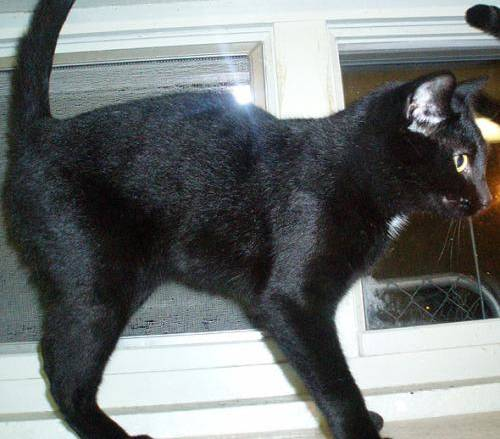

In [ ]:
image

# Resize image
Cargar todas las imágenes a la vez es un problema ya que son un total de 25000 (unos 500MB la carpeta de train). Este proceso require mucha memoria, por lo que tendremos que aplicarle un resize a cada imagen para bajarlas de resolución. Esto también nos sirve para solventar el problema de tener imágenes con distintas resoluciones.

Tamaño imagen original: (443, 500, 3)
Tamaño imagen reshape: (100, 100, 3)


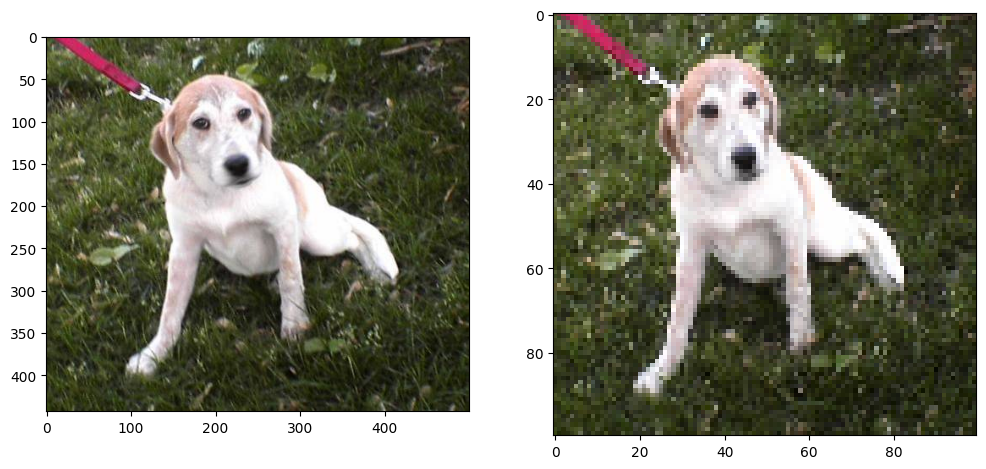

In [ ]:
plt.figure(figsize=(12, 12))

sample = random.choice(filenames)
image = imread(TRAIN_PATH / sample)
imagesmall = cv2.resize(image, (IMAGE_WIDTH, IMAGE_HEIGHT))

print("Tamaño imagen original:", image.shape)
print("Tamaño imagen reshape:", imagesmall.shape)

# Original image
plt.subplot(1, 2, 1)
plt.imshow(image)

# Resized image
plt.subplot(1, 2, 2)
plt.imshow(imagesmall);

# Color
Podríamos cargar las imágenes como blanco y negro, de esta forma se reduciría el espacio de features considerablemente al contar con un único canal

Tamaño imagen original: (196, 299)


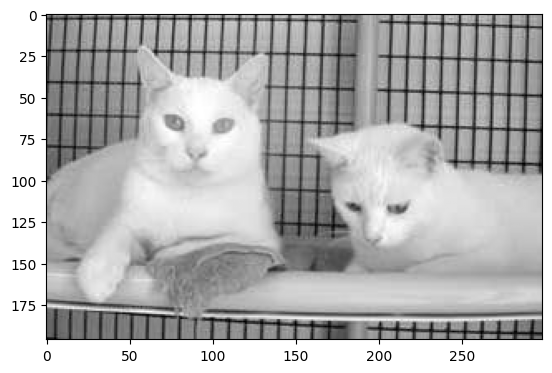

In [ ]:
sample = random.choice(filenames)

image = cv2.imread(filename = TRAIN_PATH / sample, flags = cv2.IMREAD_GRAYSCALE)

print("Tamaño imagen original:", image.shape)
plt.imshow(image, cmap='gray');

# Load data
Llega el momento de cargar los datos. Ya no estan sencillo como cuando teníamos datasets en CSVs puesto que ahora hay que cargar miles de archivos en memoria en este notebook. Para ello necesitaremos un programa iterativo que vaya recorriendo los archivos de la carpeta, cargarlos como array de numpy y almacenarlos en un objeto.

In [18]:
'''
def read_data(path, im_size):
    X = []
    Y = []

    ##### CODE #####
    # Iterar sobre todo lo que haya en path
    for file in os.listdir(path):

        # Leer la imagen a color y aplicarle el resize
        image = imread(path / file)
        smallimage = cv2.resize(image, (im_size, im_size))

        # Guardo en X
        X.append(smallimage)

        category = file.split('.')[0]
        # Miro si es perro y gato para guardar en Y
        if category == 'dog':
            Y.append(1)
        else:
            Y.append(0)


    return np.array(X), np.array(Y)


X_train, y_train = read_data(TRAIN_PATH, IMAGE_WIDTH)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
'''

(18750, 100, 100, 3)
(6250, 100, 100, 3)
(18750,)
(6250,)


In [11]:
import os
import shutil

def reorganizar_dataset(path):
    path = Path(path)
    dog_dir = path / "dog"
    cat_dir = path / "cat"
    dog_dir.mkdir(exist_ok=True)
    cat_dir.mkdir(exist_ok=True)

    for file in path.iterdir():
        if file.is_file():
            category = file.name.split('.')[0]
            if category == "dog":
                shutil.move(str(file), str(dog_dir / file.name))
            elif category == "cat":
                shutil.move(str(file), str(cat_dir / file.name))

reorganizar_dataset("PROF_train/train")



In [5]:
import tensorflow as tf

my_dataset = tf.keras.utils.image_dataset_from_directory(
    "PROF_train/train",
    image_size=(IMAGE_WIDTH, IMAGE_HEIGHT),
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)


Found 25000 files belonging to 2 classes.


In [6]:
# Validación
dataset_size = my_dataset.cardinality().numpy()
val_size = int(dataset_size * 0.2)
train_size = dataset_size - val_size

train_ds = my_dataset.take(train_size)
val_ds = my_dataset.skip(train_size)

In [7]:
# prefetch acelera
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

(100, 100, 3)


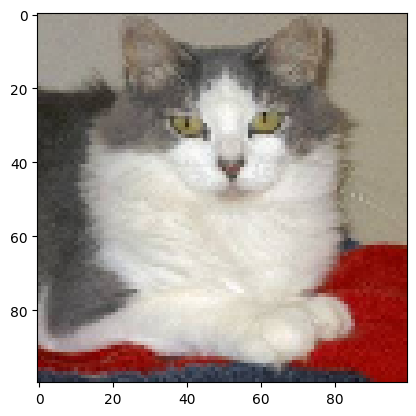

In [ ]:
#print(X_train[0].shape)
#plt.imshow(X_train[0]);

array([[[158, 154, 145],
        [157, 153, 144],
        [160, 156, 147],
        ...,
        [158, 149, 135],
        [156, 147, 131],
        [153, 144, 129]],

       [[156, 152, 143],
        [159, 155, 146],
        [160, 156, 147],
        ...,
        [157, 148, 133],
        [157, 148, 133],
        [154, 145, 130]],

       [[158, 155, 145],
        [161, 156, 147],
        [157, 153, 144],
        ...,
        [154, 145, 130],
        [157, 148, 133],
        [156, 147, 132]],

       ...,

       [[ 51,  45,  56],
        [ 63,  59,  70],
        [ 64,  58,  71],
        ...,
        [146,   6,   2],
        [146,   6,   3],
        [149,  11,   7]],

       [[ 43,  49,  63],
        [ 42,  48,  62],
        [ 57,  63,  77],
        ...,
        [150,  11,   4],
        [147,   9,   6],
        [146,  11,   7]],

       [[ 29,  35,  49],
        [ 49,  55,  69],
        [ 52,  58,  72],
        ...,
        [147,   7,   1],
        [143,   5,   2],
        [141,   7,   3]]], dtype=uint8)
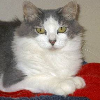

In [ ]:
X_train[0]

# Normalized data
Normalizar los datos hará que entrene mucho mejor la red, al estar todos los pixeles en la misma escala.

In [ ]:
#print("Min:", np.min(X_train))
#print("Max:", np.max(X_train))

Min: 0
Max: 255


In [19]:
#X_train = X_train / 255.0
#X_test = X_test / 255.0

#print("Min:", np.min(X_train))
#print("Max:", np.max(X_train))

Min: 0.0
Max: 1.0


# Save data
Podemos guardar los arrays de numpy en un archivo `.npz`, de tal manera que luego sea más rápido importarlo

In [ ]:
'''
np.savez(ruta_base / 'data.npz',
        X_train = X_train,
        y_train = y_train,
        X_test = X_test,
        y_test = y_test)
'''

Para cargar

In [ ]:
'''
data = np.load(ruta_base / 'data.npz')
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
'''


# Build Model

<img src="https://i.imgur.com/ebkMGGu.jpg" width="100%"/>

* **Conv Layer**: extraerá diferentes features de las imagenes
* **Pooling Layer**: Reduce las dimensiones de las imágenes tras una capa convolucional
* **Fully Connected Layer**: Tras las capas convolucionales, aplanamos las features y las introducimos como entrada de una red neuronal normal.
* **Output Layer**: Las predicciones de la red

Para el loss y la metrica, se puede usar un binary_crossentropy, al ser un target binario. O

In [11]:
from tensorflow import keras
from tensorflow.keras.optimizers import RMSprop

In [25]:


layers = [
    #keras.layers.Input(shape=IMAGE_SIZE),
    keras.layers.Rescaling(1./255, input_shape=IMAGE_SIZE),

    keras.layers.Conv2D(32, (3,3), activation='relu'),
    keras.layers.Conv2D(32, (3,3), activation='relu'), # (100, 100, 3)
    keras.layers.MaxPooling2D(pool_size=(2,2)),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Flatten(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')

]

model = keras.Sequential(layers)

model.compile(optimizer = RMSprop(learning_rate=1e-4),
             loss = 'binary_crossentropy',
             metrics = ['accuracy'])


In [24]:

# kernel 3x3  3 canales 1 bias  32 filtros
((3*3*3) + 1) * 32

896

In [15]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,290,433 (4.92 MB)

 Trainable params: 1,290,433 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

# Callbacks
#### Early Stopping

In [8]:
from keras.callbacks import EarlyStopping
earlystop = EarlyStopping(patience=5)

In [9]:
from keras.callbacks import ModelCheckpoint
mcheckpoint = ModelCheckpoint("callback_model.keras")

# Fit the model

In [18]:
history = model.fit(train_ds,
         validation_data=val_ds,
         epochs = EPOCHS,
         batch_size = BATCH_SIZE,
         callbacks = [earlystop, mcheckpoint],
         validation_split = 0.2,
         verbose=1)


Epoch 1/25
626/626 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.5933 - loss: 0.6620 - val_accuracy: 0.6530 - val_loss: 0.6200
Epoch 2/25
626/626 ━━━━━━━━━━━━━━━━━━━━ 45s 73ms/step - accuracy: 0.6825 - loss: 0.5877 - val_accuracy: 0.6882 - val_loss: 0.5755
Epoch 3/25
626/626 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.7398 - loss: 0.5229 - val_accuracy: 0.7528 - val_loss: 0.4966
Epoch 4/25
626/626 ━━━━━━━━━━━━━━━━━━━━ 40s 59ms/step - accuracy: 0.7707 - loss: 0.4791 - val_accuracy: 0.7862 - val_loss: 0.4578
Epoch 5/25
626/626 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.7964 - loss: 0.4434 - val_accuracy: 0.7886 - val_loss: 0.4429
Epoch 6/25
626/626 ━━━━━━━━━━━━━━━━━━━━ 66s 104ms/step - accuracy: 0.8092 - loss: 0.4173 - val_accuracy: 0.8068 - val_loss: 0.4182
Epoch 7/25
626/626 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.8249 - loss: 0.3893 - val_accuracy: 0.8202 - val_loss: 0.3972
Epoch 8/25
626/626 ━━━━━━━━━━━━━━━━━━━━ 36s 58ms/step - accuracy: 0.8381 - loss: 0.3657 -

Lo guardamos.

In [28]:
model.save("mi_modelo.keras")


Lo cargamos.

In [12]:

model = keras.models.load_model("mi_modelo.keras")

# Evaluate
Probemos los datos en el conjunto de test.

In [14]:

def cargar_imagen(ruta, image_size=(100,100)):
    img = tf.keras.utils.load_img(ruta, target_size=image_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # (1, 100, 100, 3)
    return img_array


In [29]:
img = cargar_imagen("test1/1.jpg", image_size=IMAGE_SIZE)

pred = model.predict(img)[0][0]


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [30]:
pred

np.float32(0.97544247)

In [22]:
carpeta = "test1"
contador = 0

for archivo in os.listdir(carpeta):
    ruta = os.path.join(carpeta, archivo)
    img = cargar_imagen(ruta, IMAGE_SIZE)
    pred = model.predict(img)[0][0]

    clase = "perro 🐶" if pred > 0.5 else "gato 🐱"
    print(f"{archivo}: {clase} (score={pred:.3f})")

    contador += 1

    if contador == 50:
      break



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
5211.jpg: gato 🐱 (score=0.000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
3142.jpg: gato 🐱 (score=0.445)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
5215.jpg: perro 🐶 (score=0.892)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
7665.jpg: perro 🐶 (score=0.989)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
3539.jpg: perro 🐶 (score=0.851)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
4231.jpg: perro 🐶 (score=0.964)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
3397.jpg: gato 🐱 (score=0.001)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
3869.jpg: gato 🐱 (score=0.000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
6774.jpg: perro 🐶 (score=0.999)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
4578.jpg: perro 🐶 (score=1.000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
5754.jpg: perro 🐶 (score=0.997)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1169.jpg: perro 🐶 (score=0.980)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
2514.jpg: perro 🐶 (score=0.988)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
4979.jpg: perro 🐶 (score=0.943)
1/1 ━━━━━━━━━━━━━━━━━━━

Matriz de confusión

In [28]:
train_ds_confusion_matrix = tf.keras.utils.image_dataset_from_directory(
    "PROF_train/train",
    image_size=(IMAGE_WIDTH,IMAGE_HEIGHT),
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="binary"
)



Found 25000 files belonging to 2 classes.


In [31]:
y_true = np.concatenate([y for x, y in train_ds_confusion_matrix], axis=0)
y_pred = model.predict(train_ds_confusion_matrix)
y_pred = (y_pred > 0.5).astype(int)


782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step


In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)


[[11685   815]
 [  819 11681]]


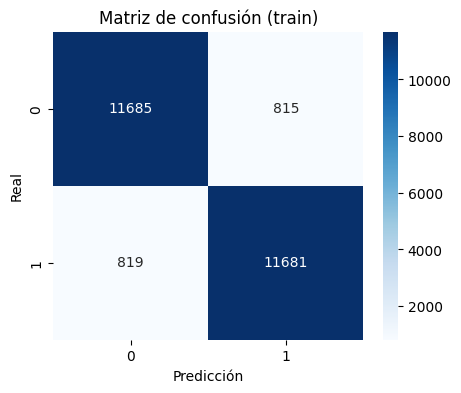

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión (train)")
plt.show()

In [34]:
(11685+11681)/(11685+11681+815+819)

0.93464

# Image data generator

In [36]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.1   # 10% para validación
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.1
)


In [37]:
train_generator = train_datagen.flow_from_directory(
    "PROF_train/train",
    target_size=(100, 100),
    batch_size=32,
    class_mode="binary",
    subset="training"
)


Found 22500 images belonging to 2 classes.


In [38]:
val_generator = val_datagen.flow_from_directory(
    "PROF_train/train",
    target_size=(100, 100),
    batch_size=32,
    class_mode="binary",
    subset="validation",
    shuffle=False
)


Found 2500 images belonging to 2 classes.


In [39]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 134s 183ms/step - accuracy: 0.5117 - loss: 0.6952 - val_accuracy: 0.6012 - val_loss: 0.6902
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 133s 176ms/step - accuracy: 0.5441 - loss: 0.6875 - val_accuracy: 0.5900 - val_loss: 0.6743
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 123s 174ms/step - accuracy: 0.6016 - loss: 0.6653 - val_accuracy: 0.6308 - val_loss: 0.6406
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 121s 172ms/step - accuracy: 0.6378 - loss: 0.6370 - val_accuracy: 0.6588 - val_loss: 0.6195
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 121s 172ms/step - accuracy: 0.6519 - loss: 0.6225 - val_accuracy: 0.6720 - val_loss: 0.5970
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 119s 169ms/step - accuracy: 0.6615 - loss: 0.6126 - val_accuracy: 0.6812 - val_loss: 0.5865
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 114s 161ms/step - accuracy: 0.6645 - loss: 0.6055 - val_accuracy: 0.6724 - val_loss: 0.5939
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 115s 164ms/step - accuracy: 0.6755 -

In [40]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 120s 170ms/step - accuracy: 0.6910 - loss: 0.5803 - val_accuracy: 0.7228 - val_loss: 0.5389
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 120s 170ms/step - accuracy: 0.7016 - loss: 0.5725 - val_accuracy: 0.7144 - val_loss: 0.5451
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 116s 165ms/step - accuracy: 0.7045 - loss: 0.5650 - val_accuracy: 0.7396 - val_loss: 0.5274
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 117s 167ms/step - accuracy: 0.7036 - loss: 0.5649 - val_accuracy: 0.7308 - val_loss: 0.5260
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 112s 159ms/step - accuracy: 0.7155 - loss: 0.5561 - val_accuracy: 0.7212 - val_loss: 0.5303
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 114s 162ms/step - accuracy: 0.7148 - loss: 0.5540 - val_accuracy: 0.7268 - val_loss: 0.5269
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 112s 159ms/step - accuracy: 0.7194 - loss: 0.5483 - val_accuracy: 0.7452 - val_loss: 0.5097
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 123s 175ms/step - accuracy: 0.7225 -

In [41]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 128s 182ms/step - accuracy: 0.7305 - loss: 0.5338 - val_accuracy: 0.7612 - val_loss: 0.4843
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 122s 173ms/step - accuracy: 0.7355 - loss: 0.5276 - val_accuracy: 0.7396 - val_loss: 0.5105
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 118s 167ms/step - accuracy: 0.7346 - loss: 0.5263 - val_accuracy: 0.7544 - val_loss: 0.4965
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 171ms/step - accuracy: 0.7400 - loss: 0.5187 - val_accuracy: 0.7712 - val_loss: 0.4707
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 120s 170ms/step - accuracy: 0.7383 - loss: 0.5179 - val_accuracy: 0.7552 - val_loss: 0.4808


In [43]:
val_eval_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.1
)

val_eval_generator = val_eval_datagen.flow_from_directory(
    "PROF_train/train",
    target_size=(100, 100),
    batch_size=32,
    class_mode="binary",
    subset="validation",
    shuffle=False
)


Found 2500 images belonging to 2 classes.


In [44]:


y_true = val_eval_generator.classes
y_pred = (model.predict(val_eval_generator) > 0.5).astype(int).ravel()


79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step


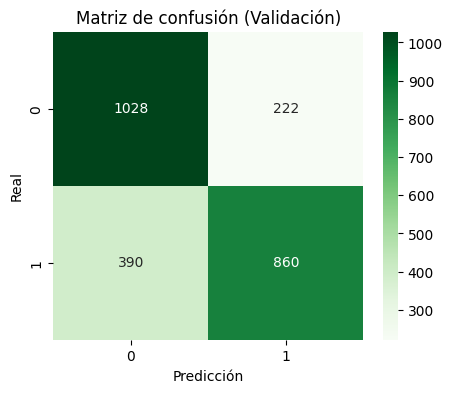

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión (Validación)")
plt.show()


In [46]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array


def mostrar_augmentations(ruta_imagen, image_size=(100,100), n_imagenes=12):
    # 1. Cargar imagen original
    img = load_img(ruta_imagen, target_size=image_size)
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)  # (1, h, w, 3)

    # 2. Definir augmentación
    datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        shear_range=0.1,
        zoom_range=0.2,
        horizontal_flip=True,
        width_shift_range=0.1,
        height_shift_range=0.1
    )

    # 3. Crear generador
    gen = datagen.flow(x, batch_size=1)

    # 4. Mostrar n imágenes aumentadas
    plt.figure(figsize=(12, 6))
    for i in range(n_imagenes):
        batch = next(gen)[0]  # tomar la imagen del batch
        plt.subplot(3, 4, i+1)
        plt.imshow(batch)
        plt.axis("off")
    plt.suptitle("Variaciones aumentadas de la imagen", fontsize=14)
    plt.show()


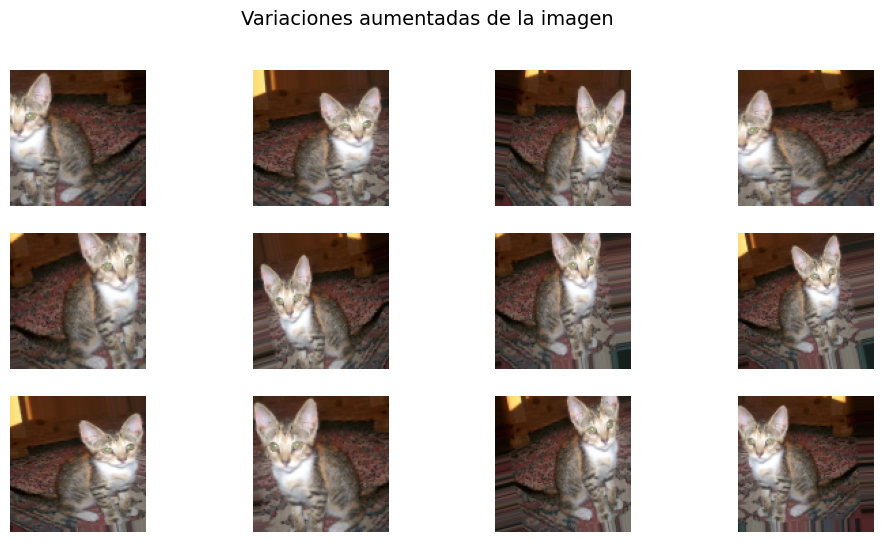

In [50]:
mostrar_augmentations("PROF_train/train/cat/cat.7.jpg", image_size=(100,100), n_imagenes=12)


In [51]:
model.save("modelo_aumentado.keras")